In [22]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

DB_URL = 'https://design-by-oz.ru/api_go'

In [3]:
def send_request(url: str, method: str, data: dict = None):
    try:
        if method.upper() == "GET":
            response = requests.get(f'{DB_URL}{url}', params=data)
        elif method.upper() == "POST":
            response = requests.post(f'{DB_URL}{url}', json=data)
        elif method.upper() == "PUT":
            response = requests.put(f'{DB_URL}{url}', json=data)
        elif method.upper() == "DELETE":
            response = requests.delete(f'{DB_URL}{url}', json=data)
        else:
            return {"error": "Unsupported HTTP method"}
        
        return {
            "status_code": response.status_code,
            "response": response.json() if response.content else None
        }
    except Exception as e:
        return {"error": str(e)}

In [23]:
data = send_request('/categoriesbydate', 'GET')
data = data['response']

In [27]:
df = pd.DataFrame(data)

In [51]:
df

,ClassificationName,InteractionResult,DateCreate,Count
0,Вопросы о регистрации и управлении учетными за...,Rating - 1,2025-03-07 00:00:00+00:00,25
1,Вопросы о регистрации и управлении учетными за...,No rating,2025-03-07 00:00:00+00:00,32
2,Вопросы о регистрации и управлении учетными за...,Rating - 2,2025-03-07 00:00:00+00:00,12
3,Вопросы о регистрации и управлении учетными за...,Rating - 3,2025-03-07 00:00:00+00:00,7
4,Вопросы о регистрации и управлении учетными за...,No responce,2025-03-07 00:00:00+00:00,3
...,...,...,...,...
1065,Технические вопросы и настройки,Rating - 1,2025-04-06 00:00:00+00:00,56
1066,Технические вопросы и настройки,No responce,2025-04-06 00:00:00+00:00,24
1067,Технические вопросы и настройки,Rating - 2,2025-04-06 00:00:00+00:00,51
1068,Технические вопросы и настройки,No rating,2025-04-06 00:00:00+00:00,107


In [ ]:
df['DateCreate'] = pd.to_datetime(df['DateCreate'], format='%Y-%m-%dT%I:%M:%S')

In [43]:
df[df['InteractionResult'] == 'Rating - 1']

,ClassificationName,InteractionResult,DateCreate,Count
0,Вопросы о регистрации и управлении учетными за...,Rating - 1,2025-03-07 00:00:00+00:00,25
9,Котировочные сессии и закупки,Rating - 1,2025-03-07 00:00:00+00:00,11
14,Ошибки сайта,Rating - 1,2025-03-07 00:00:00+00:00,13
17,Работа с контрактами,Rating - 1,2025-03-07 00:00:00+00:00,4
21,Справочная информация и поддержка,Rating - 1,2025-03-07 00:00:00+00:00,63
...,...,...,...,...
1047,Ошибки сайта,Rating - 1,2025-04-06 00:00:00+00:00,6
1050,Работа с контрактами,Rating - 1,2025-04-06 00:00:00+00:00,7
1059,Справочная информация и поддержка,Rating - 1,2025-04-06 00:00:00+00:00,48
1062,Стандартные товарные единицы (СТЕ),Rating - 1,2025-04-06 00:00:00+00:00,7


In [ ]:
d, v = [], []
for r in ['Rating - 1', 'Rating - 2', 'Rating - 3', 'No rating']:
    d.append(df[df['InteractionResult'] == r]['DateCreate'].to_list())
    v.append(df[df['InteractionResult'] == r]['Count'].to_list())

TypeError: Series.any() takes 1 positional argument but 3 were given

In [58]:
df[df['InteractionResult'] == 'No responce' | df['InteractionResult'] == 'No rating']

TypeError: Cannot perform 'ror_' with a dtyped [object] array and scalar of type [bool]

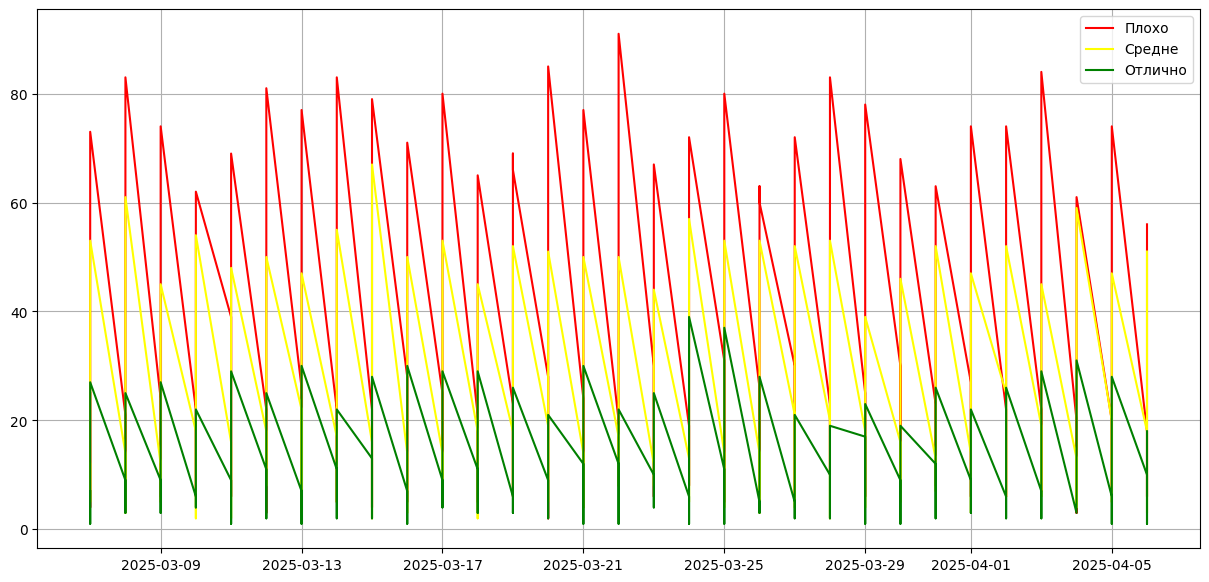

In [ ]:
plt.figure(figsize=(15, 7))
for i1, i2, c in zip(d, v, ['red', 'yellow', 'green', 'blue']):
    plt.plot(i1, i2, c=c)
plt.legend(['Плохо', 'Средне', 'Отлично', 'Без оценки'])
plt.grid()
plt.show()